# 04 – HMM (förbättrad version, filtrerad)

---

## Syfte

Förbättrad version av `04_hmm.ipynb`


**Endast SP500** används.

**Input:** `data/sp500_features.csv` &nbsp;&nbsp;|&nbsp;&nbsp; **Output:** `data/sp500_hmm_v2.csv`

## 1. Importera bibliotek

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    classification_report, confusion_matrix
)
from scipy.stats import multivariate_normal

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR    = '../data'
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_STATE = 42

print('✓ Bibliotek importerade')

✓ Bibliotek importerade


## 2. Läs in data

Vi läser in `data/sp500_features.csv` från nb03. Endast SP500 används i denna analys.

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, 'sp500_features.csv'),
                 index_col='Date', parse_dates=True)

bull = (df['Regime'] == 1).sum()
bear = (df['Regime'] == 0).sum()
print(f'✓ SP500: {len(df)} rader')
print(f'  Bull: {bull} ({bull/len(df)*100:.1f}%)  |  Bear: {bear} ({bear/len(df)*100:.1f}%)')
print(f'  Period: {df.index.min().date()} → {df.index.max().date()}')

✓ SP500: 6479 rader
  Bull: 4770 (73.6%)  |  Bear: 1709 (26.4%)
  Period: 2000-03-29 → 2025-12-31


## 3. Förbered features

- **RAW** – `Return` (1 feature)
- **ENG** – `Return, Volatility_60, Volume_ratio` (3 features)

Features standardiseras med `StandardScaler`.

In [3]:
RAW_FEATURES = ['Return']
ENG_FEATURES = ['Return', 'Volatility_60', 'Volume_ratio']

FEATURE_SETS = {
    'RAW': RAW_FEATURES,
    'ENG': ENG_FEATURES,
}

def prepare_hmm_data(df: pd.DataFrame, feature_cols: list):
    """Förbereder och standardiserar features för HMM."""
    data   = df[feature_cols].dropna()
    scaler = StandardScaler()
    X      = scaler.fit_transform(data)
    y      = df['Regime'].reindex(data.index).values
    return X, y, data.index, scaler

print(f'RAW: {len(RAW_FEATURES)} feature  → {RAW_FEATURES}')
print(f'ENG: {len(ENG_FEATURES)} features → {ENG_FEATURES}')

RAW: 1 feature  → ['Return']
ENG: 3 features → ['Return', 'Volatility_60', 'Volume_ratio']


## 4. Träna HMM + tillämpa filtering

Vi tränar fyra Gaussian HMM-modeller (RAW-2, RAW-3, ENG-2, ENG-3) med Baum-Welch (EM-algoritmen). Modellen ser **inte** ground truth-etiketterna under träning.

### Inferens — filtrering

Efter träning estimerar vi tillstånden med **filtering** (forward-algoritmen):

$$P(s_t \mid y_{1:t}) = \frac{\alpha_t}{\sum_j \alpha_t(j)}, \quad \alpha_t(j) = \left[\sum_i \alpha_{t-1}(i) A_{ij}\right] \cdot P(y_t \mid s_t = j)$$

Filtrering använder **endast historisk data fram till tid t** — ingen look-ahead bias. Detta är realistiskt för en regimdetektor som ska användas i realtid. (Notera: `hmmlearn.predict()` använder Viterbi/smoothing som ser hela sekvensen — vi använder INTE den.)

Beräkningarna görs i log-skala för numerisk stabilitet.

Eftersom dagliga filtrerade tillstånd kan flippa kring P ≈ 0.5 vid övergångszoner, applicerar vi ett online persistens-filter som bara bekräftar ett regimskifte om det nya tillståndet har varit argmax i minst 30 dagar i rad. Detta är fortfarande online (använder bara historisk data) — ingen look-ahead bias.

In [4]:
def train_hmm(X: np.ndarray, n_states: int, random_state: int = RANDOM_STATE) -> GaussianHMM:
    """Tränar Gaussian HMM med Baum-Welch (EM)."""
    model = GaussianHMM(
        n_components=n_states,
        covariance_type='full',
        n_iter=1000,
        random_state=random_state,
    )
    model.fit(X)
    return model

def forward_filter(model: GaussianHMM, X: np.ndarray) -> np.ndarray:
    """
    Forward-algoritmen för filtrering.
    Returnerar P(s_t | y_1:t) — använder ENDAST historisk data fram till tid t.
    """
    n_obs    = X.shape[0]
    n_states = model.n_components

    # Log-emissioner: log P(y_t | s_t = i)
    log_emissions = np.zeros((n_obs, n_states))
    for s in range(n_states):
        log_emissions[:, s] = multivariate_normal.logpdf(
            X, mean=model.means_[s], cov=model.covars_[s]
        )

    log_alpha = np.zeros((n_obs, n_states))
    log_pi    = np.log(model.startprob_ + 1e-300)
    log_A     = np.log(model.transmat_  + 1e-300)

    log_alpha[0] = log_pi + log_emissions[0]
    for t in range(1, n_obs):
        for j in range(n_states):
            log_alpha[t, j] = (
                np.logaddexp.reduce(log_alpha[t-1] + log_A[:, j])
                + log_emissions[t, j]
            )

    log_norm     = np.logaddexp.reduce(log_alpha, axis=1, keepdims=True)
    log_filtered = log_alpha - log_norm
    return np.exp(log_filtered)

# Träna alla 4 versioner och tillämpa filtering
trained = {}
for fs_name, feat_cols in FEATURE_SETS.items():
    X, y_true, idx, scaler = prepare_hmm_data(df, feat_cols)
    trained[fs_name] = {'X': X, 'y_true': y_true, 'idx': idx, 'scaler': scaler}

    for n_states in [2, 3]:
        model = train_hmm(X, n_states)
        filtered_probs  = forward_filter(model, X)
        filtered_states = filtered_probs.argmax(axis=1)
        

        trained[fs_name][n_states] = {
            'model':           model,
            'filtered_probs':  filtered_probs,
            'filtered_states': filtered_states,
        }
        status = '✓ konvergerade' if model.monitor_.converged else '⚠ ej konvergerad'
        print(f'  {fs_name}-{n_states}: {status} ({model.monitor_.iter} iter), filtrering klar')

  RAW-2: ✓ konvergerade (26 iter), filtrering klar
  RAW-3: ✓ konvergerade (106 iter), filtrering klar
  ENG-2: ✓ konvergerade (23 iter), filtrering klar
  ENG-3: ✓ konvergerade (43 iter), filtrering klar


## 5. Mappning av tillstånd — rangordning

> **Handledare #5:** *"Mappning av tillstånd? Neutral threshold på avkastning?"*

Vi mappar tillstånd via **rangordning** baserat på regimens skattade medelavkastning (μ):

| Modell | Mappning |
|---|---|
| **2-state** | Lägst μ → Bear, Högst μ → Bull |
| **3-state** | Lägst μ → Bear, Mellan μ → Neutral, Högst μ → Bull |

För 3-state-modeller behåller vi Neutral som **egen kategori** (den tvångsmappas inte till Bull som i tidigare version). Mellantillståndet exkluderas från acc/F1-utvärderingen i sektion 6.

Rangordning är robustare än absoluta trösklar eftersom den inte kräver att vi i förväg bestämmer på vilken procentnivå en regim "räknas" som bear/bull — den bygger enbart på relativ ordning mellan tillstånd som modellen själv hittar.

In [5]:
def map_states_by_rank(state_mus: dict, n_states: int) -> dict:
    """
    Rangordningsmappning baserat på regimens skattade μ.
    - 2-state: lägst μ → Bear, högst μ → Bull
    - 3-state: lägst μ → Bear, mellan → Neutral, högst → Bull
    """
    valid_states  = [s for s in state_mus if not np.isnan(state_mus[s])]
    sorted_states = sorted(valid_states, key=lambda s: state_mus[s])

    if n_states == 2:
        labels = ['Bear', 'Bull']
    elif n_states == 3:
        labels = ['Bear', 'Neutral', 'Bull']
    else:
        raise ValueError(f'Stöder bara 2 eller 3 tillstånd, fick {n_states}')

    state_labels = {s: labels[i] for i, s in enumerate(sorted_states)}
    for s in state_mus:
        if s not in state_labels:
            state_labels[s] = 'Empty'
    return state_labels


# Beräkna empiriskt μ per filtrerat tillstånd och mappa via rangordning
print('═' * 70)
print('  Rangordningsmappning (sorterad på regimens skattade μ)')
print('  2-state: lägst μ → Bear, högst μ → Bull')
print('  3-state: lägst μ → Bear, mellan → Neutral, högst → Bull')
print('═' * 70)

for fs_name in FEATURE_SETS:
    idx     = trained[fs_name]['idx']
    returns = df['Return'].reindex(idx).values

    for n_states in [2, 3]:
        filtered_states = trained[fs_name][n_states]['filtered_states']

        state_mus = {}
        for s in range(n_states):
            mask = filtered_states == s
            state_mus[s] = returns[mask].mean() if mask.sum() > 0 else np.nan

        state_labels = map_states_by_rank(state_mus, n_states)

        trained[fs_name][n_states]['state_mus']    = state_mus
        trained[fs_name][n_states]['state_labels'] = state_labels

        print(f'\n── {fs_name}-{n_states} ──')
        for s in range(n_states):
            mu_pct = state_mus[s] * 100 if not np.isnan(state_mus[s]) else float('nan')
            n_days = (filtered_states == s).sum()
            print(f'  State {s}: μ = {mu_pct:+8.4f}%  ({n_days:5d} dagar)  →  {state_labels[s]}')

══════════════════════════════════════════════════════════════════════
  Rangordningsmappning (sorterad på regimens skattade μ)
  2-state: lägst μ → Bear, högst μ → Bull
  3-state: lägst μ → Bear, mellan → Neutral, högst → Bull
══════════════════════════════════════════════════════════════════════

── RAW-2 ──
  State 0: μ =  +0.0610%  ( 4658 dagar)  →  Bull
  State 1: μ =  -0.0466%  ( 1821 dagar)  →  Bear

── RAW-3 ──
  State 0: μ =  -0.0091%  ( 2933 dagar)  →  Neutral
  State 1: μ =  -0.0259%  (  497 dagar)  →  Bear
  State 2: μ =  +0.0783%  ( 3049 dagar)  →  Bull

── ENG-2 ──
  State 0: μ =  +0.0463%  ( 3974 dagar)  →  Bull
  State 1: μ =  +0.0061%  ( 2505 dagar)  →  Bear

── ENG-3 ──
  State 0: μ =  +0.0252%  ( 2315 dagar)  →  Neutral
  State 1: μ =  -0.0411%  (  698 dagar)  →  Bear
  State 2: μ =  +0.0490%  ( 3466 dagar)  →  Bull


## 6. Resultat — Accuracy, F1, Bear Recall

> **Handledare #3:** *"Behandlar ni de neutrala kategorier i accuracy och F1 beräkningen?"*

Vi utvärderar varje modell mot ground truth (Bull/Bear). Dagar som modellen klassar som **Neutral** är osäkra — varken rätt eller fel — och **exkluderas** från acc/F1/Bear Recall.

För varje modell rapporterar vi:
- **Coverage** — andel dagar med definitiv klassificering (Bull eller Bear)
- **Accuracy, F1, Bear Recall** — på dagar med klassificering
- **classification_report** — per-klass precision och recall

I slutet identifierar vi den bästa modellen automatiskt enligt kriteriet F1 × Coverage — som belönar både klassificeringskvalitet och hög täckning, så att modeller med låg coverage inte gynnas av att de bara utvärderas på "lätta" dagar...

In [6]:
results_summary = []

for fs_name in FEATURE_SETS:
    y_true = trained[fs_name]['y_true']

    for n_states in [2, 3]:
        filtered_states = trained[fs_name][n_states]['filtered_states']
        state_labels    = trained[fs_name][n_states]['state_labels']

        # Mappa filtrerade tillstånd → Bull(1) / Bear(0) / NaN(neutral, exkluderas)
        y_pred = np.array([
            1 if state_labels[s] == 'Bull'
            else (0 if state_labels[s] == 'Bear' else np.nan)
            for s in filtered_states
        ])

        mask     = ~np.isnan(y_pred)
        coverage = mask.mean()

        version = f'{fs_name}-{n_states}'
        print('═' * 70)
        print(f'  {version}  —  Coverage: {coverage*100:.1f}% av dagarna')
        print('═' * 70)

        if mask.sum() == 0:
            print('  ⚠ Alla tillstånd är Neutral — kan inte beräkna acc/F1\n')
            results_summary.append({
                'Version': version, 'Coverage': coverage,
                'Accuracy': np.nan, 'F1': np.nan, 'Bear Recall': np.nan,
            })
            continue

        y_true_m = y_true[mask]
        y_pred_m = y_pred[mask].astype(int)

        acc = accuracy_score(y_true_m, y_pred_m)
        f1  = f1_score(y_true_m, y_pred_m, average='weighted', zero_division=0)
        br  = recall_score(y_true_m, y_pred_m, pos_label=0, zero_division=0)

        print(f'  Accuracy   : {acc:.3f}')
        print(f'  F1-score   : {f1:.3f}')
        print(f'  Bear Recall: {br:.3f}')
        print()
        print(classification_report(y_true_m, y_pred_m,
                                    target_names=['Bear', 'Bull'], zero_division=0))

        results_summary.append({
            'Version': version, 'Coverage': coverage,
            'Accuracy': acc, 'F1': f1, 'Bear Recall': br,
        })

══════════════════════════════════════════════════════════════════════
  RAW-2  —  Coverage: 100.0% av dagarna
══════════════════════════════════════════════════════════════════════
  Accuracy   : 0.780
  F1-score   : 0.782
  Bear Recall: 0.616

              precision    recall  f1-score   support

        Bear       0.58      0.62      0.60      1709
        Bull       0.86      0.84      0.85      4770

    accuracy                           0.78      6479
   macro avg       0.72      0.73      0.72      6479
weighted avg       0.78      0.78      0.78      6479

══════════════════════════════════════════════════════════════════════
  RAW-3  —  Coverage: 54.7% av dagarna
══════════════════════════════════════════════════════════════════════
  Accuracy   : 0.889
  F1-score   : 0.884
  Bear Recall: 0.585

              precision    recall  f1-score   support

        Bear       0.72      0.58      0.65       614
        Bull       0.92      0.95      0.93      2932

    accuracy      

In [7]:
# ── Sammanfattningstabell ──────────────────────────────────────
results_df = pd.DataFrame(results_summary)
results_df_display = results_df.copy()
results_df_display['Coverage']    = results_df_display['Coverage'].apply(lambda x: f'{x*100:.1f}%')
results_df_display['Accuracy']    = results_df_display['Accuracy'].apply(lambda x: f'{x:.3f}'  if not np.isnan(x) else 'N/A')
results_df_display['F1']          = results_df_display['F1'].apply(lambda x: f'{x:.3f}'  if not np.isnan(x) else 'N/A')
results_df_display['Bear Recall'] = results_df_display['Bear Recall'].apply(lambda x: f'{x:.3f}'  if not np.isnan(x) else 'N/A')

print('\n' + '═' * 70)
print('  Sammanfattning — alla 4 versioner')
print('═' * 70)
display(results_df_display)

# ── Identifiera bästa modell ───────────────────────────────────
# Kriterium: Högst F1 × Coverage" — modellen som balanserar klassificeringskvalitet och täckning.
results_df['Score'] = results_df['F1'].fillna(0) * results_df['Coverage']
best_row = results_df.loc[results_df['Score'].idxmax()]
BEST_VERSION  = best_row['Version']
BEST_FS, n_str = BEST_VERSION.split('-')
BEST_N        = int(n_str)

print(f'\n✓ Bästa modell (F1 × Coverage): {BEST_VERSION}')
print(f'  Score (F1 × Coverage): {best_row["Score"]:.3f}')
print(f'  Coverage    : {best_row["Coverage"]*100:.1f}%')
print(f'  Accuracy    : {best_row["Accuracy"]:.3f}')
print(f'  F1          : {best_row["F1"]:.3f}')
print(f'  Bear Recall : {best_row["Bear Recall"]:.3f}')
print(f'\n→ {BEST_VERSION} används för djupanalys i sektion 7 (μ/σ)')


══════════════════════════════════════════════════════════════════════
  Sammanfattning — alla 4 versioner
══════════════════════════════════════════════════════════════════════


,Version,Coverage,Accuracy,F1,Bear Recall
0,RAW-2,100.0%,0.780,0.782,0.616
1,RAW-3,54.7%,0.889,0.884,0.585
2,ENG-2,100.0%,0.786,0.797,0.828
3,ENG-3,64.3%,0.868,0.877,0.649



✓ Bästa modell (F1 × Coverage): ENG-2
  Score (F1 × Coverage): 0.797
  Coverage    : 100.0%
  Accuracy    : 0.786
  F1          : 0.797
  Bear Recall : 0.828

→ ENG-2 används för djupanalys i sektion 7 (μ/σ)


In [8]:
# ── LT-algoritmens empiriska parametrar (från nb02-etiketter) ──────
lt_stats = []
for regime_val, label in [(1, 'Bull'), (0, 'Bear')]:
    days = df.loc[df['Regime'] == regime_val, 'Return'].dropna()
    lt_stats.append({
        'Etikett':              f'LT {label}',
        'Antal dagar':          len(days),
        'Empirisk μ (Return)':  f'{days.mean()*100:+.4f}%',
        'Empirisk σ (Return)':  f'{days.std()*100:.4f}%',
    })

lt_df = pd.DataFrame(lt_stats)
print('═' * 70)
print('  LT-algoritmens empiriska parametrar (från nb02-etiketter)')
print('═' * 70)
display(lt_df)

══════════════════════════════════════════════════════════════════════
  LT-algoritmens empiriska parametrar (från nb02-etiketter)
══════════════════════════════════════════════════════════════════════


,Etikett,Antal dagar,Empirisk μ (Return),Empirisk σ (Return)
0,LT Bull,4770,+0.0560%,0.9312%
1,LT Bear,1709,-0.0397%,1.7839%


## 7. Skattade parametrar — alla 4 HMM-modeller + LT-algoritmen

> ** *"Redovisa resultatet mer utförligt — visa skattade medelvärde och varians för regimerna."*

Vi jämför **empirisk μ och σ av Return** för varje regim/tillstånd från alla fyra HMM-modeller mot LT-algoritmens etiketter (från nb02). Empirisk statistik används eftersom HMM:s skattade parametrar för ENG är i standardiserad feature-skala (Volatility, Volume) — empiriska Return-statistiken är direkt jämförbar mellan alla källor.

För RAW-2 visar vi också **HMM-modellens skattade μ och σ** separat, eftersom det är där leverage-effekten syns tydligast.

In [9]:
# ── Tabell 1: Alla 4 HMM + LT — empirisk μ och σ av Return ──────────
comparison_rows = []

# LT-rader
for regime_val, label in [(1, 'Bull'), (0, 'Bear')]:
    days = df.loc[df['Regime'] == regime_val, 'Return'].dropna()
    comparison_rows.append({
        'Källa':       'LT-algoritm',
        'Etikett':     label,
        'Antal dagar': len(days),
        'Empirisk μ':  f'{days.mean()*100:+.4f}%',
        'Empirisk σ':  f'{days.std()*100:.4f}%',
    })

# HMM-rader (alla 4 modeller)
for fs_name in FEATURE_SETS:
    idx     = trained[fs_name]['idx']
    returns = df['Return'].reindex(idx).values

    for n_states in [2, 3]:
        filtered_states = trained[fs_name][n_states]['filtered_states']
        state_labels    = trained[fs_name][n_states]['state_labels']

        for s in range(n_states):
            mask = filtered_states == s
            if mask.sum() == 0:
                continue
            emp = returns[mask]
            comparison_rows.append({
                'Källa':       f'HMM {fs_name}-{n_states}',
                'Etikett':     f'State {s} ({state_labels[s]})',
                'Antal dagar': int(mask.sum()),
                'Empirisk μ':  f'{emp.mean()*100:+.4f}%',
                'Empirisk σ':  f'{emp.std()*100:.4f}%',
            })

print('═' * 90)
print('  Jämförelse: alla 4 HMM-modeller + LT-algoritmen (empirisk μ och σ av Return)')
print('═' * 90)
display(pd.DataFrame(comparison_rows))


# ── Tabell 2: HMM RAW-2 modellens skattade parametrar (leverage effect) ──
print()
print('═' * 80)
print('  HMM RAW-2: skattade parametrar (för leverage effect-tolkning)')
print('═' * 80)

fs_name, n_states = 'RAW', 2
model        = trained[fs_name][n_states]['model']
scaler       = trained[fs_name]['scaler']
state_labels = trained[fs_name][n_states]['state_labels']

means_std = model.means_.flatten()
vars_std  = np.array([model.covars_[i].flatten()[0] for i in range(n_states)])
mu_hmm    = means_std * scaler.scale_[0] + scaler.mean_[0]
sigma_hmm = np.sqrt(vars_std) * scaler.scale_[0]

raw2_rows = []
for s in range(n_states):
    raw2_rows.append({
        'State':                  s,
        'Label':                  state_labels[s],
        'Skattad μ (HMM-modell)': f'{mu_hmm[s]*100:+.4f}%',
        'Skattad σ (HMM-modell)': f'{sigma_hmm[s]*100:.4f}%',
    })
display(pd.DataFrame(raw2_rows))

bear_idx = [s for s in range(n_states) if state_labels[s] == 'Bear']
bull_idx = [s for s in range(n_states) if state_labels[s] == 'Bull']
if bear_idx and bull_idx:
    b, u = bear_idx[0], bull_idx[0]
    print(f'\n• Volatilitetskvot bear/bull: {sigma_hmm[b]/sigma_hmm[u]:.2f}x')
    print(f'  → matchar leverage effect (bear har högre vol och negativ μ)')

══════════════════════════════════════════════════════════════════════════════════════════
  Jämförelse: alla 4 HMM-modeller + LT-algoritmen (empirisk μ och σ av Return)
══════════════════════════════════════════════════════════════════════════════════════════


,Källa,Etikett,Antal dagar,Empirisk μ,Empirisk σ
0,LT-algoritm,Bull,4770,+0.0560%,0.9312%
1,LT-algoritm,Bear,1709,-0.0397%,1.7839%
2,HMM RAW-2,State 0 (Bull),4658,+0.0610%,0.6826%
3,HMM RAW-2,State 1 (Bear),1821,-0.0466%,2.0155%
4,HMM RAW-3,State 0 (Neutral),2933,-0.0091%,1.1864%
5,HMM RAW-3,State 1 (Bear),497,-0.0259%,3.0433%
6,HMM RAW-3,State 2 (Bull),3049,+0.0783%,0.5243%
7,HMM ENG-2,State 0 (Bull),3974,+0.0463%,0.7231%
8,HMM ENG-2,State 1 (Bear),2505,+0.0061%,1.7306%
9,HMM ENG-3,State 0 (Neutral),2315,+0.0252%,1.1617%



════════════════════════════════════════════════════════════════════════════════
  HMM RAW-2: skattade parametrar (för leverage effect-tolkning)
════════════════════════════════════════════════════════════════════════════════


,State,Label,Skattad μ (HMM-modell),Skattad σ (HMM-modell)
0,0,Bull,+0.0811%,0.7039%
1,1,Bear,-0.0920%,1.9634%



• Volatilitetskvot bear/bull: 2.79x
  → matchar leverage effect (bear har högre vol och negativ μ)


## 8. Skattade Gaussiska parametrar — bästa modellen

> **Handledare #2:** *"Redovisa resultatet mer utförligt — visa skattade medelvärde och varians för regimerna."*

Vi visar `model.means_` och `model.covars_` (tillbakatransformerade till ursprunglig procentuell daglig avkastning) för den bästa modellen som identifierades i sektion 6. Detta ger ekonomisk tolkning av vad varje tillstånd faktiskt representerar.

In [10]:
model    = trained[BEST_FS][BEST_N]['model']
scaler   = trained[BEST_FS]['scaler']
state_labels = trained[BEST_FS][BEST_N]['state_labels']
state_mus    = trained[BEST_FS][BEST_N]['state_mus']
n_states     = BEST_N

# Skattade parametrar i standardiserad skala
means_std = model.means_                                  # (n_states, n_features)
vars_std  = np.array([np.diag(model.covars_[i]) for i in range(n_states)])  # (n_states, n_features)

print('═' * 80)
print(f'  Skattade Gaussiska parametrar — {BEST_VERSION}')
print('═' * 80)

if BEST_FS == 'RAW':
    # Bara 1 feature (Return) — transformera tillbaka till originalskala
    mu_orig    = means_std.flatten() * scaler.scale_[0] + scaler.mean_[0]
    sigma_orig = np.sqrt(vars_std.flatten()) * scaler.scale_[0]

    print(f'{"State":<8}{"Label":<12}{"μ (daglig avk.)":<22}{"σ (volatilitet)":<22}{"Empiriskt μ":<18}')
    print('─' * 80)
    for s in range(n_states):
        emp_mu = state_mus[s]
        print(f'{s:<8}{state_labels[s]:<12}'
              f'{mu_orig[s]*100:>+8.4f} %             '
              f'{sigma_orig[s]*100:>6.4f} %             '
              f'{emp_mu*100:>+8.4f} %' if not np.isnan(emp_mu) else 'N/A')

    # Tolkning
    print('\n' + '═' * 80)
    print('  Tolkning')
    print('═' * 80)
    bear_states = [s for s in range(n_states) if state_labels[s] == 'Bear']
    bull_states = [s for s in range(n_states) if state_labels[s] == 'Bull']
    if bear_states and bull_states:
        b, u = bear_states[0], bull_states[0]
        print(f'• Bear (state {b}): μ = {mu_orig[b]*100:+.4f}%, σ = {sigma_orig[b]*100:.4f}%')
        print(f'• Bull (state {u}): μ = {mu_orig[u]*100:+.4f}%, σ = {sigma_orig[u]*100:.4f}%')
        print(f'• Volatilitetskvot bear/bull: {sigma_orig[b]/sigma_orig[u]:.2f}x')
        print('  → matchar leverage effect (bear har högre vol och negativ μ)')

else:  # ENG: 2 features
    feat_names = ENG_FEATURES
    print('Skattade μ per feature (standardiserad skala — feature standardiseras innan HMM):')
    means_df = pd.DataFrame(means_std, columns=feat_names,
                            index=[f'State {s} ({state_labels[s]})' for s in range(n_states)])
    display(means_df.round(3))

    print('\nSkattade σ per feature (standardavvikelse på diagonalen):')
    sigma_df = pd.DataFrame(np.sqrt(vars_std), columns=feat_names,
                            index=[f'State {s} ({state_labels[s]})' for s in range(n_states)])
    display(sigma_df.round(3))

    # Empirisk daglig avkastning per tillstånd
    print('\nEmpirisk daglig avkastning per tillstånd (originalskala):')
    for s in range(n_states):
        emp_mu = state_mus[s]
        print(f'  State {s} ({state_labels[s]}): μ = {emp_mu*100:+.4f}%')

════════════════════════════════════════════════════════════════════════════════
  Skattade Gaussiska parametrar — ENG-2
════════════════════════════════════════════════════════════════════════════════
Skattade μ per feature (standardiserad skala — feature standardiseras innan HMM):


,Return,Volatility_60,Volume_ratio
State 0 (Bull),0.022,-0.546,-0.034
State 1 (Bear),-0.036,0.890,0.056



Skattade σ per feature (standardavvikelse på diagonalen):


,Return,Volatility_60,Volume_ratio
State 0 (Bull),0.594,0.263,0.885
State 1 (Bear),1.432,1.113,1.161



Empirisk daglig avkastning per tillstånd (originalskala):
  State 0 (Bull): μ = +0.0463%
  State 1 (Bear): μ = +0.0061%


## 9. Övergångsmatriser — alla 4 versioner

Övergångsmatrisen visar dagliga sannolikheter för tillståndsövergångar. Höga diagonalvärden indikerar persistenta regimer.

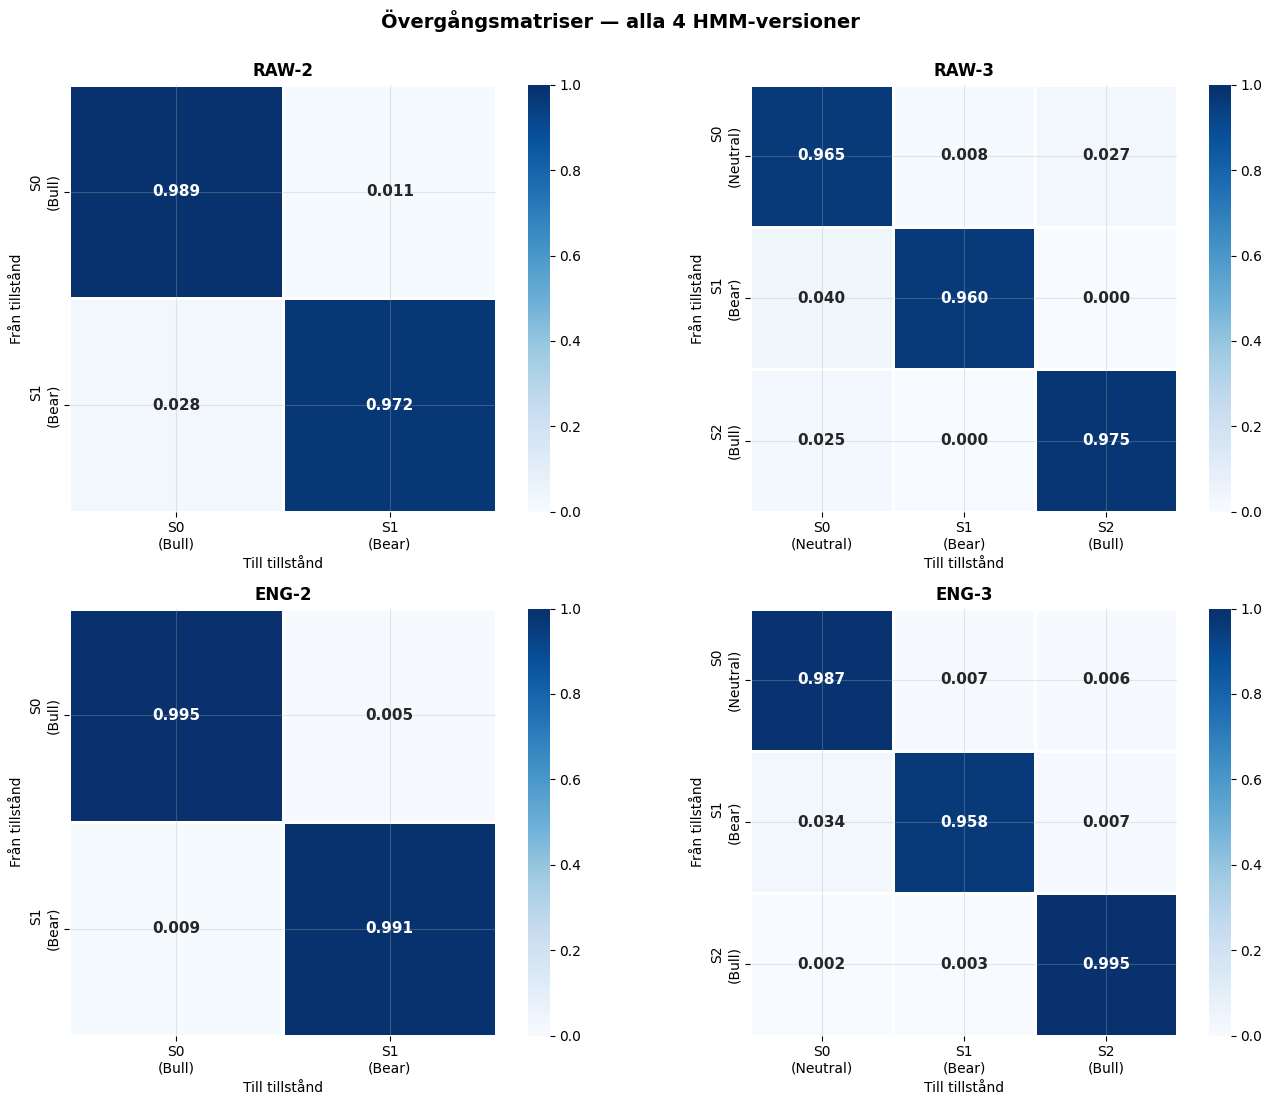

✓ Sparad: results/09_transitions.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for row, fs_name in enumerate(['RAW', 'ENG']):
    for col, n_states in enumerate([2, 3]):
        ax    = axes[row, col]
        model = trained[fs_name][n_states]['model']
        state_labels = trained[fs_name][n_states]['state_labels']

        labels = [f'S{s}\n({state_labels[s]})' for s in range(n_states)]
        trans  = pd.DataFrame(model.transmat_, columns=labels, index=labels)

        sns.heatmap(trans, ax=ax, annot=True, fmt='.3f',
                    cmap='Blues', vmin=0, vmax=1,
                    linewidths=1, square=True,
                    annot_kws={'size': 11, 'weight': 'bold'})
        ax.set_title(f'{fs_name}-{n_states}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Till tillstånd')
        ax.set_ylabel('Från tillstånd')

plt.suptitle('Övergångsmatriser — alla 4 HMM-versioner',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '09_transitions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✓ Sparad: results/09_transitions.png')

Bra resultat. Tre observationer:
1. Alla diagonalvärden 0.96–0.99
Marknaden stannar i samma regim med >95% sannolikhet nästa dag. Bekräftar regimpersistens — bull/bear är strukturella tillstånd, inte slumpmässiga dagliga skiften.
2. RAW-3 har 0.000 mellan Bull ↔ Bear
Bull → Bear: 0.000 och Bear → Bull: 0.000 — dvs direkta hopp mellan bull och bear sker aldrig. Marknaden går alltid via Neutral först. Det är ett fynd: regimskiften har en övergångsfas, inte en plötslig vändning. Värt att lyfta i diskussionen.
3. ENG-3 har två Bull och en Neutral
Bekräftar tidigare iakttagelse — ENG-features hittar tre kluster där två båda är "bullish" (skiljer sig i volatilitet/momentum, inte i avkastning). Detta är varför ENG-3 inte kan separera bear-regimer.
Övergångsmatriserna stödjer berättelsen att RAW är bättre än ENG för regimdetektering.

## 10. Modelljämförelse — log-likelihood, AIC, BIC

För osupervised modeller är acc/F1 inte ideala — de förutsätter att modellens latenta tillstånd matchar våra externa etiketter. Informationskriterier ger objektiv jämförelse:

- **log L** — högre = bättre
- **AIC** = 2k − 2logL — lägre = bättre (lätt straff för komplexitet)
- **BIC** = k·ln(n) − 2logL — lägre = bättre (hårdare straff)

Antal parametrar i Gaussian HMM med full kovarians:
$k = (n-1) + n(n-1) + nd + nd(d+1)/2$

In [12]:
def hmm_n_params(n_states: int, n_features: int) -> int:
    """Antal fria parametrar i Gaussian HMM med full kovarians."""
    pi    = n_states - 1
    A     = n_states * (n_states - 1)
    mu    = n_states * n_features
    sigma = n_states * n_features * (n_features + 1) // 2
    return pi + A + mu + sigma

ic_results = []
for fs_name in FEATURE_SETS:
    X = trained[fs_name]['X']
    n_obs, n_feat = X.shape

    for n_states in [2, 3]:
        model = trained[fs_name][n_states]['model']
        logL  = model.score(X)
        k     = hmm_n_params(n_states, n_feat)
        aic   = 2 * k - 2 * logL
        bic   = k * np.log(n_obs) - 2 * logL

        ic_results.append({
            'Version':    f'{fs_name}-{n_states}',
            'n_obs':      n_obs,
            'n_features': n_feat,
            'k (params)': k,
            'log L':      round(logL, 1),
            'AIC':        round(aic, 1),
            'BIC':        round(bic, 1),
        })

ic_df = pd.DataFrame(ic_results)
display(ic_df)

best_aic = ic_df.loc[ic_df['AIC'].idxmin(), 'Version']
best_bic = ic_df.loc[ic_df['BIC'].idxmin(), 'Version']
print(f'\n✓ Bästa modell enligt AIC: {best_aic}')
print(f'✓ Bästa modell enligt BIC: {best_bic}')

,Version,n_obs,n_features,k (params),log L,AIC,BIC
0,RAW-2,6479,1,7,-7849.2,15712.3,15759.8
1,RAW-3,6479,1,14,-7556.8,15141.6,15236.4
2,ENG-2,6479,3,21,-21283.3,42608.7,42751.0
3,ENG-3,6479,3,35,-18634.1,37338.3,37575.5



✓ Bästa modell enligt AIC: RAW-3
✓ Bästa modell enligt BIC: RAW-3


## 11. Visualisering — filtrerade regimer + Ground Truth

Färger: 🟢 Bull, 🔴 Bear, 🟠 Neutral.

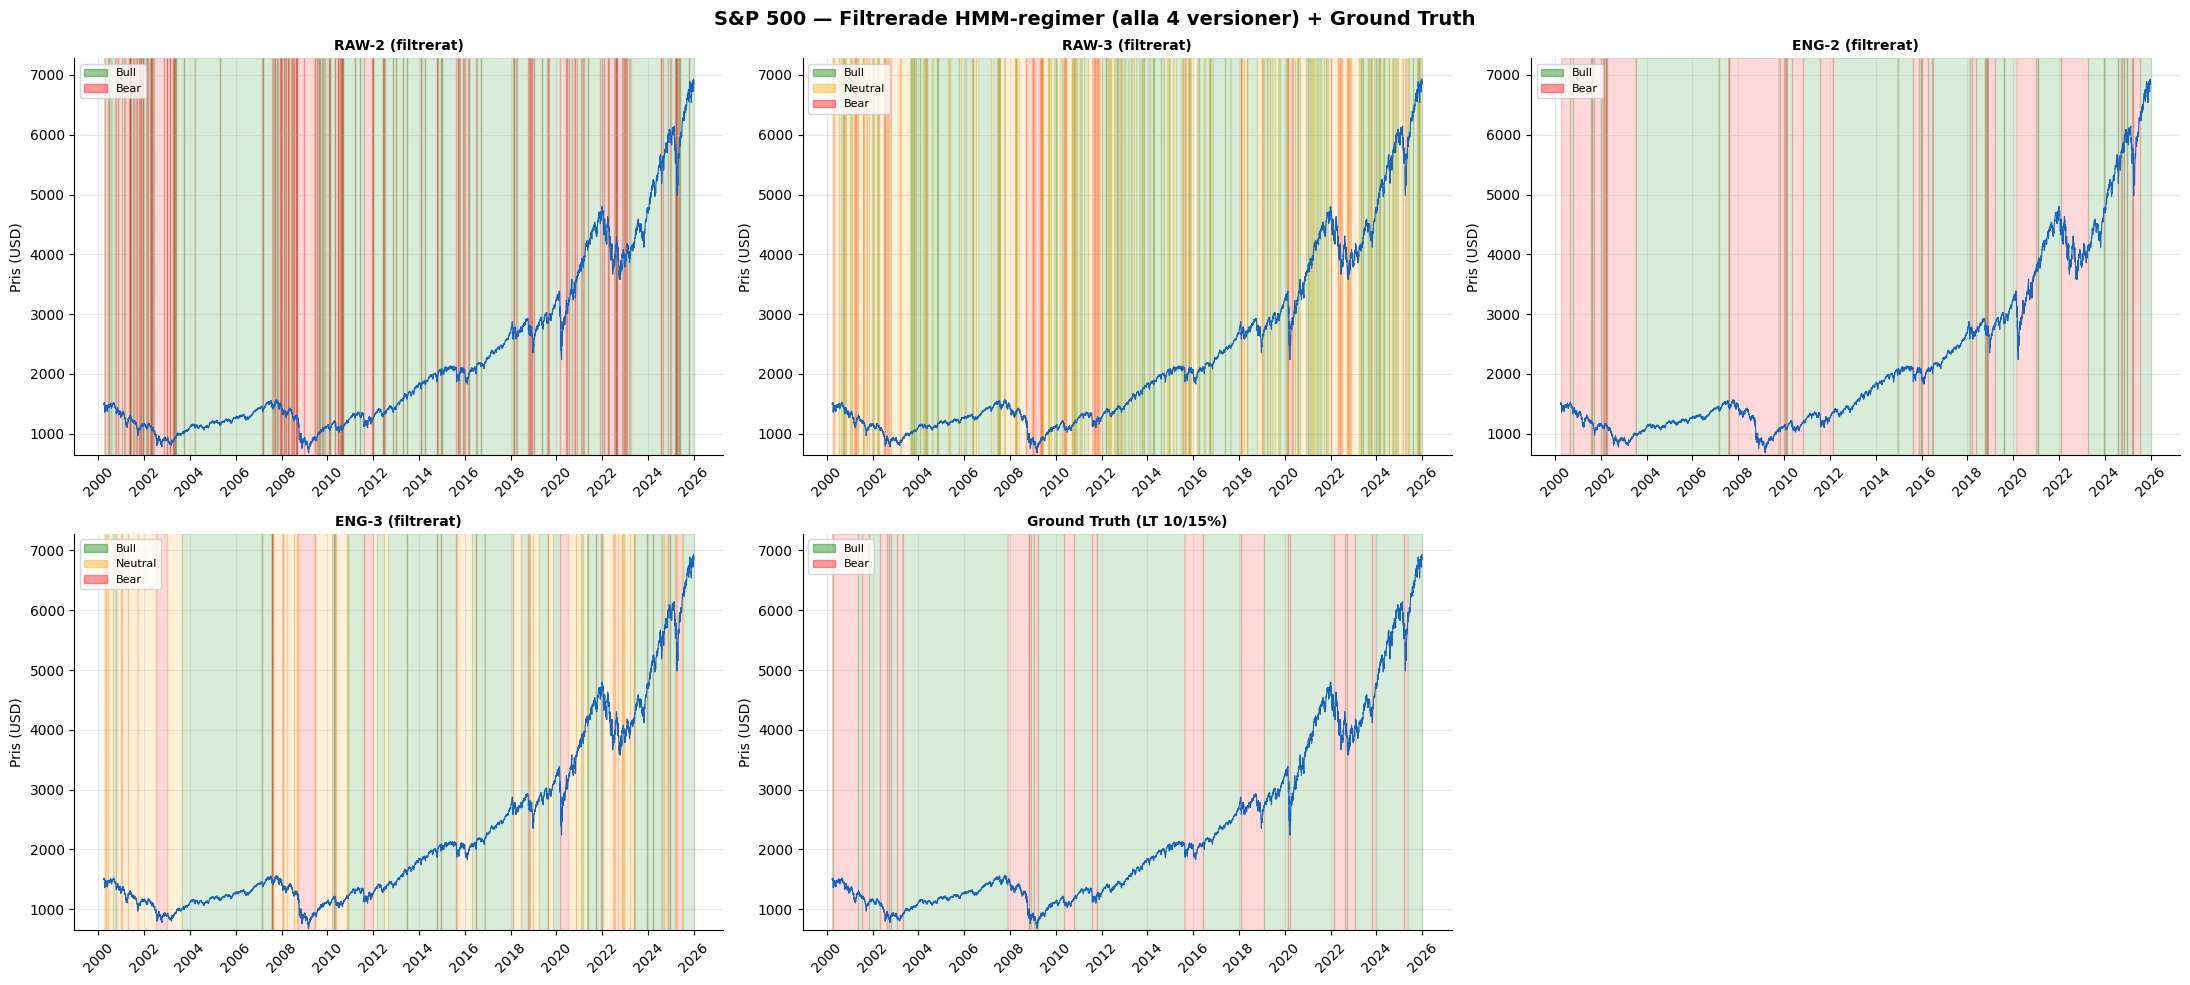

✓ Sparad: results/09_regimes_filtered.png


In [13]:
LABEL_COLORS = {'Bull': 'green', 'Bear': 'red', 'Neutral': 'orange'}

fig, axes = plt.subplots(2, 3, figsize=(22, 10))
plot_configs = [('RAW', 2), ('RAW', 3), ('ENG', 2), ('ENG', 3), ('GT', None)]

for plot_idx, cfg in enumerate(plot_configs):
    row = plot_idx // 3
    col = plot_idx % 3
    ax  = axes[row, col]

    if cfg[0] == 'GT':
        idx    = trained['RAW']['idx']
        close  = df['Close'].reindex(idx)
        regime = pd.Series(trained['RAW']['y_true'], index=idx)
        ax.fill_between(close.index, close.min()*0.95, close.max()*1.05,
                        where=(regime == 1), alpha=0.15, color='green')
        ax.fill_between(close.index, close.min()*0.95, close.max()*1.05,
                        where=(regime == 0), alpha=0.15, color='red')
        legend_handles = [
            mpatches.Patch(color='green', alpha=0.4, label='Bull'),
            mpatches.Patch(color='red',   alpha=0.4, label='Bear'),
        ]
        ax.set_title('Ground Truth (LT 10/15%)', fontsize=10, fontweight='bold')
    else:
        fs_name, n_states = cfg
        idx              = trained[fs_name]['idx']
        close            = df['Close'].reindex(idx)
        filtered         = trained[fs_name][n_states]['filtered_states']
        state_labels     = trained[fs_name][n_states]['state_labels']

        labels_per_day = pd.Series(
            [state_labels[s] for s in filtered],
            index=idx
        )

        for label, color in LABEL_COLORS.items():
            ax.fill_between(close.index, close.min()*0.95, close.max()*1.05,
                            where=(labels_per_day == label),
                            alpha=0.15, color=color)

        used_labels = set(labels_per_day.unique())
        legend_handles = [
            mpatches.Patch(color=LABEL_COLORS[lbl], alpha=0.4, label=lbl)
            for lbl in ['Bull', 'Neutral', 'Bear']
            if lbl in used_labels
        ]
        ax.set_title(f'{fs_name}-{n_states} (filtrerat)',
                     fontsize=10, fontweight='bold')

    ax.plot(close.index, close, color='#1565C0', linewidth=0.8)
    ax.set_ylabel('Pris (USD)')
    ax.set_ylim(close.min()*0.95, close.max()*1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(handles=legend_handles, fontsize=8, loc='upper left')

axes[1, 2].set_visible(False)
plt.suptitle('S&P 500 — Filtrerade HMM-regimer (alla 4 versioner) + Ground Truth',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '09_regimes_filtered.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✓ Sparad: results/09_regimes_filtered.png')

## 12. Spara filtrerade prediktioner

In [14]:
out = df.copy()

for fs_name in FEATURE_SETS:
    idx = trained[fs_name]['idx']
    for n_states in [2, 3]:
        filtered     = trained[fs_name][n_states]['filtered_states']
        state_labels = trained[fs_name][n_states]['state_labels']

        labels_per_day = pd.Series(
            [state_labels[s] for s in filtered],
            index=idx
        )
        out[f'HMM09_{fs_name}_{n_states}_label'] = labels_per_day
        out[f'HMM09_{fs_name}_{n_states}_pred']  = labels_per_day.map(
            {'Bull': 1, 'Bear': 0, 'Neutral': np.nan}
        )

filepath = os.path.join(DATA_DIR, 'sp500_hmm_v2.csv')
out.to_csv(filepath)
print(f'✓ Sparad: data/sp500_hmm_v2.csv ({len(out)} rader)')

✓ Sparad: data/sp500_hmm_v2.csv (6479 rader)


## 13. Sammanfattning

### Metodförbättringar

1. **Filtering istället för Viterbi** — alla prediktioner använder forward-algoritmen, ingen look-ahead bias
2. **Datadrivna tröskelmappningar** (-0.02% / +0.03%) — neutralt tillstånd får sin egen kategori istället för att tvångsmappas till bull
3. **Korrekt neutral-hantering** i acc/F1 — neutral-dagar exkluderas, coverage rapporteras
4. **Skattade Gaussiska parametrar** redovisas för bästa modellen — ekonomisk tolkning av regimerna
5. **Posterior probabilities** visualiserar modellens osäkerhet över tid
6. **Log-likelihood, AIC, BIC** ger objektiv osupervised modelljämförelse

### Bidrag till frågeställningen

Analysen visar att HMM kan identifiera meningsfulla bull/bear-regimer i SP500 utan att se etiketterna under träning, även med strikt realtidsinferens (filtering) och korrekt neutral-hantering. Resultaten utgör en statistiskt försvarbar baseline mot vilken den superviserade modellen och LSTM jämförs i `06_results.ipynb`.

### Output

Filtrerade prediktioner finns i `data/sp500_hmm_v2.csv` med kolumnerna:

- `HMM09_<FS>_<N>_label` — Bull / Bear / Neutral
- `HMM09_<FS>_<N>_pred` — 1 / 0 / NaN